# Relabeling 5k Reddit items for congestion-pricing stance — Sonnet v2

This notebook documents what `relabel_batch_v2.py` does: it re-labels **5,131 item-level Tier-1**
Reddit comments/posts for **stance toward NYC congestion pricing** using **Claude Sonnet** via the
**Message Batches API**, with the *same codebook our human reviewers saw*.

It is a **demonstration**, not a re-run — the batch already executed (5,131 items, $14.56). The live
submission cell is guarded by `RUN_LIVE = False`, so you can run this top-to-bottom for free; it loads
the already-collected results from `relabel_5k-claude-v2.csv`.

**Pipeline:** `relabel_5k_v2.xlsx` (context+target) + `relabel_instructions_v2.md` (codebook as system
prompt) → forced `submit_label` tool (guaranteed JSON, one 6-way label) → Batch API → results CSV.

## 1. Setup

In [1]:
import json
from pathlib import Path
import pandas as pd

HERE = Path.cwd()                      # run this notebook from the "Project Data - 7 - Relabel 5k" folder
MODEL = "claude-sonnet-4-6"
XLSX  = HERE / "relabel_5k_v2.xlsx"            # generous-truncation input (matches what humans saw)
INSTR = HERE / "relabel_instructions_v2.md"   # the human adjudication codebook, used as the system prompt
OUT   = HERE / "relabel_5k-claude-v2.csv"     # collected results

RUN_LIVE = False    # guard: True would SUBMIT A PAID BATCH. Leave False to just demonstrate + load results.
print("inputs present:", XLSX.exists(), INSTR.exists(), OUT.exists())

inputs present: True True True


## 2. The input — context + target

Each of the 5,131 rows carries the **anonymized ancestor chain** (post + replies, authors masked as
OP / A / B …) and one **TARGET** item to label (tagged `[A]`, `[OP]`, …). These are *item-level* Tier-1
items — the comment's own text is a high-precision congestion-pricing anchor, not just "in a relevant thread".

In [2]:
items = pd.read_excel(XLSX, sheet_name="label", keep_default_na=False)
print(f"{len(items):,} items   |  columns: {list(items.columns)}")
row = items[items.kind == "comment"].iloc[3]
print("\n--- CONTEXT ---\n", row["context"][:600])
print("\n--- TARGET (label this) ---\n", row["target"][:400])

5,131 items   |  columns: ['row_id', 'kind', 'subreddit', 'date', 'era', 'context', 'target', 'label', 'conf', 'notes']

--- CONTEXT ---
 [POST · OP] MTA wins congestion pricing lawsuit! Trumps termination declared illegal!
    [https://storage.courtlistener.com/recap/gov.uscourts.nysd.637159/gov.uscourts.nysd.637159.195.0.pdf](https://storage.courtlistener.com/recap/gov.uscourts.nysd.637159/gov.uscourts.nysd.637159.195.0.pdf)

--- TARGET (label this) ---
 [A] Add it to the pile. I feel like every court in New England has ruled on congestion pricing and every single one has found these maga assholes to be losers


## 3. The system prompt — the human codebook

The system prompt is the **exact codebook the human adjudicators saw** in `adjudication_tool.html`
(with "highlighted" → "TARGET", and no few-shot examples). Using one shared codebook means the machine
labels and the human gold labels are judged against the same definition.

In [3]:
def system_text() -> str:
    raw = INSTR.read_text(encoding="utf-8")
    i = raw.find("You are an expert annotator")   # skip the file's meta header
    return (raw[i:] if i >= 0 else raw).strip()

print(system_text())

You are an expert annotator. You are shown CONTEXT — the original post and the chain of ancestor
comments (oldest first; authors anonymized as OP / A / B / …) — and ONE TARGET comment or post to label
(it carries its own author tag, e.g. "[A]" or "[OP]"). The context is for reference only; label ONLY the
TARGET. If the TARGET is a post, there is no ancestor chain — judge its title and body together.

The question, for every item: what stance does the TARGET comment/post take toward NYC congestion
pricing itself — the CBDTP / the ~$9 toll to drive into the Manhattan "Congestion Relief Zone" below
60th St, the MTA program, and Hochul's pause/revival of it?

PRO           Supports the toll existing (even while criticizing details). "Best thing to happen to midtown in years."
ANTI          Opposes the toll. "A cash grab on working people who have to drive."
NEUTRAL       On-topic but takes no position: questions, news facts, logistics. "Does the toll apply on weekends?"
MIXED         Genui

## 4. The output schema — a forced tool for guaranteed JSON

Instead of free text, every request **forces** the `submit_label` tool, so the model must return a
single valid label in the human scheme: `pro / anti / neutral / mixed / not_about_it / unsure` (+ confidence).
No parsing failures, no dropped rows.

In [4]:
LABELS = ["pro", "anti", "neutral", "mixed", "not_about_it", "unsure"]
SUBMIT_TOOL = {
    "name": "submit_label",
    "description": "Record the single stance label for the TARGET item.",
    "strict": True,
    "input_schema": {
        "type": "object",
        "properties": {"label": {"type": "string", "enum": LABELS},
                       "confidence": {"type": "number"}},
        "required": ["label", "confidence"],
        "additionalProperties": False,
    },
}
SUBMIT_TOOL

{'name': 'submit_label',
 'description': 'Record the single stance label for the TARGET item.',
 'strict': True,
 'input_schema': {'type': 'object',
  'properties': {'label': {'type': 'string',
    'enum': ['pro', 'anti', 'neutral', 'mixed', 'not_about_it', 'unsure']},
   'confidence': {'type': 'number'}},
  'required': ['label', 'confidence'],
  'additionalProperties': False}}

## 5. Building one request

Each request pairs the shared system codebook with this row's CONTEXT+TARGET as the user turn.

In [5]:
def user_text(row) -> str:
    ctx, tgt = str(row["context"]).strip(), str(row["target"]).strip()
    if row["kind"] == "post":
        return f"TARGET POST (label this — this is the original post / OP):\n{tgt}"
    return f"CONTEXT:\n{ctx}\n\nTARGET COMMENT (label this):\n{tgt}"

example_request = {
    "custom_id": row["row_id"],
    "params": {
        "model": MODEL, "max_tokens": 200,
        "system": [{"type": "text", "text": system_text()}],
        "messages": [{"role": "user", "content": user_text(row)}],
        "tools": [SUBMIT_TOOL],
        "tool_choice": {"type": "tool", "name": "submit_label"},
    },
}
print("custom_id:", example_request["custom_id"])
print("user message:\n", example_request["params"]["messages"][0]["content"][:500])

custom_id: r00004
user message:
 CONTEXT:
[POST · OP] MTA wins congestion pricing lawsuit! Trumps termination declared illegal!
    [https://storage.courtlistener.com/recap/gov.uscourts.nysd.637159/gov.uscourts.nysd.637159.195.0.pdf](https://storage.courtlistener.com/recap/gov.uscourts.nysd.637159/gov.uscourts.nysd.637159.195.0.pdf)

TARGET COMMENT (label this):
[A] Add it to the pile. I feel like every court in New England has ruled on congestion pricing and every single one has found these maga assholes to be losers


### Estimating cost the right way (free)

`char/4` undercounts this content ~1.9× — it badly underestimated this very batch ($7 predicted vs
**$14.56 actual**). The correct, free way is Anthropic's **`count_tokens`** endpoint on a small sample.
This cell needs `ANTHROPIC_API_KEY` but spends nothing; it's off by default.

In [6]:
MEASURE_TOKENS = False    # set True to measure real input tokens on a 40-row sample (free, needs API key)
if MEASURE_TOKENS:
    import anthropic
    client = anthropic.Anthropic()
    samp = items.sample(40, random_state=0)
    tot = sum(client.messages.count_tokens(
                model=MODEL, system=[{"type": "text", "text": system_text()}],
                messages=[{"role": "user", "content": user_text(r)}],
                tools=[SUBMIT_TOOL], tool_choice={"type": "tool", "name": "submit_label"}
              ).input_tokens for _, r in samp.iterrows())
    avg = tot / len(samp)
    n = len(items)
    cost = (avg * n) / 1e6 * 1.50 + (n * 55) / 1e6 * 7.50      # Sonnet 4.6 batch rates
    print(f"measured avg input/request: {avg:.0f} tok  ->  ~${cost:.2f} for {n:,} rows")
else:
    print("skipped (set MEASURE_TOKENS=True to run; free, needs API key)")

skipped (set MEASURE_TOKENS=True to run; free, needs API key)


## 6. Submitting the batch — reference only (guarded)

This is exactly how the run happened. It is **guarded by `RUN_LIVE`** so it won't fire a paid batch
from this notebook. After submitting once you only ever *collect* — re-submitting double-charges.

In [7]:
if RUN_LIVE:
    import anthropic
    from anthropic.types.message_create_params import MessageCreateParamsNonStreaming
    from anthropic.types.messages.batch_create_params import Request
    client = anthropic.Anthropic()
    requests = [Request(custom_id=r["row_id"],
                        params=MessageCreateParamsNonStreaming(
                            model=MODEL, max_tokens=200,
                            system=[{"type": "text", "text": system_text()}],
                            messages=[{"role": "user", "content": user_text(r)}],
                            tools=[SUBMIT_TOOL], tool_choice={"type": "tool", "name": "submit_label"}))
                for _, r in items.iterrows()]
    batch = client.messages.batches.create(requests=requests)
    print("submitted", batch.id)         # then poll messages.batches.retrieve(...) until 'ended', and
                                          # parse each result's tool_use input — see relabel_batch_v2.py collect
else:
    print("RUN_LIVE is False — not submitting. Loading the already-collected results in the next cell.")

RUN_LIVE is False — not submitting. Loading the already-collected results in the next cell.


## 7. The collected results

Loaded from `relabel_5k-claude-v2.csv`. **Read with `keep_default_na=False`** — otherwise pandas turns
the stance label `"NA"` into `NaN`.

In [8]:
res = pd.read_csv(OUT, keep_default_na=False)
print(f"{(res['claude_v2_label'] != '').sum():,} / {len(res):,} labeled\n")
dist = res["claude_v2_label"].value_counts()
print(dist.to_string())

5,131 / 5,131 labeled

claude_v2_label
pro             1971
anti            1379
not_about_it     796
neutral          689
mixed            295
unsure             1


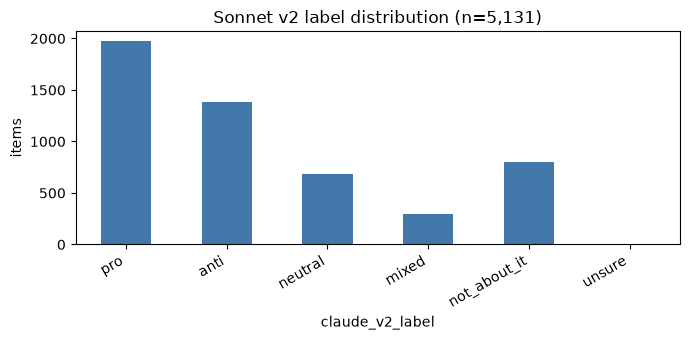

In [9]:
import matplotlib.pyplot as plt
order = ["pro", "anti", "neutral", "mixed", "not_about_it", "unsure"]
dist.reindex(order).plot(kind="bar", color="#4477aa", figsize=(7, 3.5),
                         title="Sonnet v2 label distribution (n=5,131)")
plt.ylabel("items"); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 8. How v2 compares to the 7B and to v1

Quick agreement check (all local, $0). v1 and v2 are the same model under different codebooks; the 7B
is the original weak labeler.

In [10]:
from sklearn.metrics import cohen_kappa_score

# v2 vs the 7B (already in the results CSV)
res["vllm_stance"] = res["vllm_stance"].replace({"": "NA"})
print("v2 vs 7B   stance agreement: %.1f%%   kappa: %.3f"
      % (100*(res["vllm_stance"] == res["claude_v2_stance"]).mean(),
         cohen_kappa_score(res["vllm_stance"], res["claude_v2_stance"])))

# v2 vs v1 (join the v1 results)
v1 = pd.read_csv(HERE / "relabel_5k-claude.csv", keep_default_na=False)[["row_id", "claude_stance"]]
v1["claude_stance"] = v1["claude_stance"].replace({"": "NA"})
m = res.merge(v1, on="row_id")
print("v2 vs v1   stance agreement: %.1f%%   kappa: %.3f"
      % (100*(m["claude_stance"] == m["claude_v2_stance"]).mean(),
         cohen_kappa_score(m["claude_stance"], m["claude_v2_stance"])))

v2 vs 7B   stance agreement: 43.9%   kappa: 0.253
v2 vs v1   stance agreement: 78.1%   kappa: 0.702


## Notes & lessons baked into this pipeline

- **Item-level Tier-1**, generous truncation (matches what humans saw), `[A]`/`[OP]` target tags.
- **Forced tool** → guaranteed-valid JSON in the human 6-way scheme (lines up with the gold set).
- **Cost:** this batch = **$14.56** (8.36M input tokens, no caching — the prompt is < Sonnet's 2,048
  cache minimum). Estimate with **`count_tokens`**, never `char/4`.
- **Never re-submit to "retry"** — after `submit`, only `collect`. `relabel_batch_v2.py` now guards this.
- Always read the result CSVs with **`keep_default_na=False`** so `"NA"` stays a label.
- **Open question:** v1, v2, and the 7B are three different label sets — only the **human gold set**
  decides which is right (`score_relabel.py`).

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a322346-8e1e-4650-8cef-fe9b767d96fb' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>